In [ ]:
import sys
import os


sys.path.append(os.path.abspath(".."))

In [ ]:
from graph.workflow import app
from langchain_core.messages import HumanMessage


c:\Users\Lenovo\Desktop\QualiChainAI\Backend\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading weights: 100%|██████████| 391/391 [00:00<00:00, 2749.75it/s]


In [8]:
from pymongo import MongoClient
client = MongoClient("mongodb://localhost:27017/")

db = client["qualichainAI"]

capa_collection = db["capa_plans"]
report_collection = db["audit_reports"]

In [3]:
from langchain_core.messages import HumanMessage

result = app.invoke(
    {
        "messages": [
            HumanMessage(
                content="Génère un plan CAPA pour la checklist CHK-002"
            )
        ]
    }
)



In [4]:
result

{'messages': [HumanMessage(content='Génère un plan CAPA pour la checklist CHK-002', additional_kwargs={}, response_metadata={}, id='b4d84fe5-4afe-4593-9616-949201f799fe'),
  AIMessage(content='{\n    "resume": "Plan CAPA basé sur les non-conformités identifiées lors de l\'audit, aligné sur les exigences réglementaires en matière de gestion des équipements, des procédures et de la qualité des produits pharmaceutiques.",\n    "actions": [\n        {\n            "probleme": "Deux sondes de température dans la chambre froide non recalibrées depuis 12 mois.",\n            "cause_racine": "Absence de procédure régulière de recalibration des équipements de mesure.",\n            "action_corrective": "Recalibrer immédiatement les sondes et vérifier leur fonctionnement.",\n            "action_preventive": "Mettre en place un calendrier de vérification et de recalibration trimestrielle des équipements de mesure.",\n            "priorite": "Haute",\n            "responsable": "Service Maintenanc

In [6]:
import json

content = result["messages"][-1].content

# Transformer le JSON texte en dictionnaire Python
capa_data = json.loads(content)


# Construire le document CAPA
capa_plan = {
    "checklist_id": "CHK-002",
    
    **capa_data
}


# Sauvegarder dans MongoDB
insert_result = capa_collection.insert_one(capa_plan)

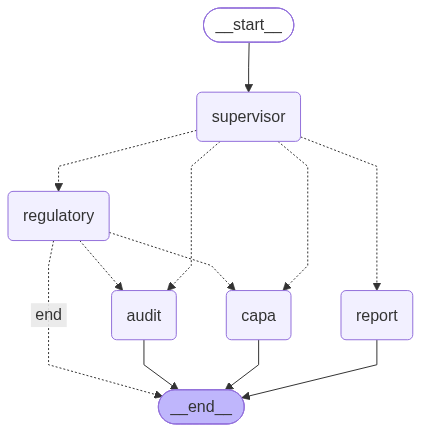

In [8]:
from graph.workflow import app
from IPython.display import Image, display

display(Image(app.get_graph().draw_mermaid_png()))

In [3]:
report_1 = app.invoke({
        "messages": [
            HumanMessage(
                content="Génère un rapport audit pour la checklist CHK-001"
            )
        ]
    })

report_1

{'messages': [HumanMessage(content='Génère un rapport audit pour la checklist CHK-001', additional_kwargs={}, response_metadata={}, id='615b53e3-e56f-4509-9abc-8677530764ae'),
  AIMessage(content='{\n    "titre": "Rapport d\'audit",\n    "informations_generales": {\n        "type_audit": "Audit entrepôt de stockage pharmaceutique",\n        "site_audit": "Site de stockage vaccins",\n        "date_audit": "20/08/2026",\n        "responsable": "Hana Houimli"\n    },\n    "objectif": "Vérifier la conformité des processus de stockage et de conservation des vaccins",\n    "perimetre": "L\'audit couvre les systèmes de contrôle de température, la chaîne de froid, la traçabilité des lots et les procédures de gestion des non-conformités",\n    "resume_executif": {\n        "score_conformite": 76,\n        "statut_global": "Conforme avec observations",\n        "total_points": 25,\n        "conformes": 19,\n        "non_conformes": 6,\n        "partiellement_conformes": 0,\n        "non_applicab

In [4]:
report_1["messages"][-1].content

'{\n    "titre": "Rapport d\'audit",\n    "informations_generales": {\n        "type_audit": "Audit entrepôt de stockage pharmaceutique",\n        "site_audit": "Site de stockage vaccins",\n        "date_audit": "20/08/2026",\n        "responsable": "Hana Houimli"\n    },\n    "objectif": "Vérifier la conformité des processus de stockage et de conservation des vaccins",\n    "perimetre": "L\'audit couvre les systèmes de contrôle de température, la chaîne de froid, la traçabilité des lots et les procédures de gestion des non-conformités",\n    "resume_executif": {\n        "score_conformite": 76,\n        "statut_global": "Conforme avec observations",\n        "total_points": 25,\n        "conformes": 19,\n        "non_conformes": 6,\n        "partiellement_conformes": 0,\n        "non_applicables": 0\n    },\n    "non_conformites": [\n        {"section": "Contrôle de la température", "question": "Les enregistreurs de température affichent-ils des données continues avec des intervalles 

In [ ]:

report_2 = app.invoke({
        "messages": [
            HumanMessage(
                content="Un écart de température se répète depuis plusieurs semaines malgré les interventions du personnel. Quel plan CAPA faut-il établir ?"
            )
        ]
    })

report_2

{'messages': [HumanMessage(content='Génère un plan CAPA pour la checklist CHK-003', additional_kwargs={}, response_metadata={}, id='70793b70-67bd-4826-9514-745f5041b11b'),
  AIMessage(content='{\n    "resume": "Plan CAPA basé sur les non-conformités identifiées lors de l\'audit, conformément aux exigences réglementaires en matière de gestion des produits et de traçabilité.",\n    "actions": [\n        {\n            "probleme": "Présence d\'humidité dans les espaces de stockage.",\n            "cause_racine": "Maintenance insuffisante des zones de stockage.",\n            "action_corrective": "Nettoyer et désinfecter les zones affectées, installer des systèmes de déshumidification.",\n            "action_preventive": "Mettre en place un programme de surveillance régulière de l\'humidité et des inspections trimestrielles.",\n            "priorite": "Haute",\n            "responsable": "Service maintenance",\n            "echeance": "Dans les 7 jours",\n            "statut_action": "Ouve

In [6]:
report_2["messages"][-1].content

'{\n    "titre": "Rapport d\'audit CHK-002",\n    "informations_generales": {\n        "type_audit": "Audit fournisseur pharmaceutique",\n        "site_audit": "Fournisseur médicaments",\n        "date_audit": "20/08/2026",\n        "responsable": "Hana Houimli"\n    },\n    "objectif": "Vérifier la conformité du fournisseur pharmaceutique aux normes qualité et réglementations applicables",\n    "perimetre": "L\'audit couvre les processus de gestion des équipements, des documents, des formations et des actions correctives",\n    "resume_executif": {\n        "score_conformite": 81.82,\n        "statut_global": "Conforme avec observations",\n        "total_points": 22,\n        "conformes": 18,\n        "non_conformes": 4,\n        "partiellement_conformes": 0,\n        "non_applicables": 0\n    },\n    "non_conformites": [\n        {\n            "section": "Moyens Humains et Matériels",\n            "question": "Le matériel de stockage (réfrigérateurs, entrepôts) est-il calibré et vér

In [10]:
import json

content = report_2["messages"][-1].content

# Transformer le JSON texte en dictionnaire Python
report_data = json.loads(content)


# Construire le document CAPA
report = {
    "checklist_id": "CHK-002",
    
    **report_data
}


# Sauvegarder dans MongoDB
insert_result =report_collection.insert_one(report)